# # 04 — Promotion Impact Analysis (MVP 01)
#
# **Pipeline stage: descriptive promotion analytics over the Dunnhumby dataset.**
#
# This notebook answers **what happened** around every campaign — before / during / after —
# before we model the counterfactual in `05_baseline_forecasting`.
#
# ```
# Raw transactions + campaign calendar + display/mailer calendar
#   -> promotion timeline analysis
#   -> before / during / after comparison (sales, revenue, quantity, discount)
#   -> promotion uplift visualization
#   -> baseline descriptive statistics
#   -> campaign_summary.parquet | campaign_timeline.parquet | promoted_products.parquet
# ```
#
# All loading / validation helpers are shared with notebooks 05-09 via `notebooks/utils/`,
# so this stage is directly portable to backend services (each export is a service input).


In [1]:
# --- environment --------------------------------------------------------------
import sys
import json
import warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

def _find_root() -> Path:
    p = Path.cwd()
    for q in [p, *p.parents]:
        if (q / "data" / "raw" / "transaction_data.csv").exists():
            return q
    return p

ROOT = _find_root()
sys.path.insert(0, str(ROOT / "notebooks"))

from utils import data as UD
from utils import features as UF
from utils import common as UC

logger = UC.setup_logging("promotion_analysis")


@dataclass(frozen=True)
class Config:
    """Single source of truth for MVP 01 parameters."""
    seed: int = 42
    pre_days: int = 28                 # baseline window before campaign start
    post_days: int = 28                # post window after campaign end
    top_products_per_campaign: int = 10
    force_rebuild_causal: bool = False
    max_day: int = 711            # last DAY present in transaction_data.csv
    output_dir: Path = UC.pipeline_dir("promotion_analysis")
    figures_dir: Path = UC.figures_dir("promotion_analysis")


CFG = Config()
UC.set_seed(CFG.seed)
print(f"ROOT        : {ROOT}")
print(f"Output dir  : {CFG.output_dir}")
print(f"Figures dir : {CFG.figures_dir}")


ROOT        : /home/mhseddighi/Projects/promotion-intelligence
Output dir  : /home/mhseddighi/Projects/promotion-intelligence/outputs/promotion_analysis
Figures dir : /home/mhseddighi/Projects/promotion-intelligence/outputs/promotion_analysis/figures


# ## 1. Data Loading
#
# Typed loaders keep memory low and make the schema explicit. The display/mailer
# calendar (`causal_data.csv`, 36.8M rows) is aggregated once to product-week level
# and cached as parquet so notebooks 05-09 never re-read the huge raw file.


In [2]:
logger.info("Loading raw data with typed loaders ...")
tx = UD.load_transactions_fast()
products = UD.load_products()
campaign_desc = UD.load_campaign_desc()
campaign_table = UD.load_campaign_table()
campaign_desc = UD.campaign_days(campaign_desc)

causal_weekly = UD.load_or_build_causal_weekly(
    force=CFG.force_rebuild_causal, logger=logger
)

print(f"transactions : {tx.shape}")
print(f"products     : {products.shape}")
print(f"campaigns    : {campaign_desc.shape}")
print(f"causal_weekly: {causal_weekly.shape}")


22:00:01 | INFO    | promotion_analysis | Loading raw data with typed loaders ...


22:00:03 | INFO    | promotion_analysis | Loading cached causal_weekly from /home/mhseddighi/Projects/promotion-intelligence/data/processed/causal_weekly.parquet


transactions : (2595732, 12)
products     : (92353, 7)
campaigns    : (30, 6)
causal_weekly: (2049187, 4)


In [3]:
def validate_loading() -> None:
    """Contract checks for the raw loading layer (runs every time)."""
    assert tx.shape[0] > 1_000_000, "transactions too small"
    assert tx.shape[1] == 12, "transactions schema changed"
    assert products["PRODUCT_ID"].is_unique, "duplicate PRODUCT_ID"
    assert campaign_desc.shape[0] >= 30, "campaign table too small"
    assert campaign_desc["duration_days"].min() > 0, "invalid campaign duration"
    assert causal_weekly.shape[0] > 1_000_000, "causal aggregation failed"
    assert campaign_desc["START_DAY"].min() >= 1, "campaign starts before day 1"
    assert campaign_desc["START_DAY"].max() <= CFG.max_day, "campaign starts after data ends"
    extended = campaign_desc[campaign_desc["END_DAY"] > CFG.max_day]
    if not extended.empty:
        print(f"NOTE: {len(extended)} campaign(s) end after the last transaction day "
              f"({CFG.max_day}); their windows are clipped for comparison.")

    sold, master = set(tx["PRODUCT_ID"].unique()), set(products["PRODUCT_ID"].unique())
    assert not (sold - master), "sold products missing from product master"

    UC.check_no_nan_inf(campaign_desc[["CAMPAIGN", "START_DAY", "END_DAY", "duration_days"]],
                        context="campaign_desc")
    UC.check_no_nan_inf(causal_weekly, context="causal_weekly")
    print("PASS: data loading validated")


validate_loading()


NOTE: 1 campaign(s) end after the last transaction day (711); their windows are clipped for comparison.
PASS [nan/inf] campaign_desc: no NaN/Inf in 30 rows


PASS [nan/inf] causal_weekly: no NaN/Inf in 2,049,187 rows
PASS: data loading validated


# ## 2. Promotion Timeline Analysis
#
# Campaigns are marketing windows sent to households. We analyse them on the retailer
# timeline: when they run, how long they last, and how they overlap. Overlapping
# campaigns are a known confound for before/during/after analysis — we quantify it
# explicitly instead of hiding it.


In [4]:
timeline_cols = ["CAMPAIGN", "DESCRIPTION", "START_DAY", "END_DAY", "duration_days"]
print(campaign_desc[timeline_cols].sort_values("START_DAY").to_string(index=False))

print("\n=== Campaign type counts ===")
print(campaign_desc["DESCRIPTION"].value_counts().to_string())

print("\n=== Duration statistics (days) ===")
print(campaign_desc["duration_days"].describe().to_string())

overlaps = UD.campaign_overlap_table(campaign_desc)
print(f"\n=== Overlapping campaign pairs: {len(overlaps)} ===")
if not overlaps.empty:
    print(overlaps.sort_values("overlap_days", ascending=False).head(8).to_string(index=False))
    n_overlapped = campaign_desc["CAMPAIGN"].isin(
        set(overlaps["campaign_a"]) | set(overlaps["campaign_b"])
    ).sum()
    print(f"Campaigns that overlap another campaign: {n_overlapped}/{len(campaign_desc)}")
else:
    print("No overlapping campaigns.")


 CAMPAIGN DESCRIPTION  START_DAY  END_DAY  duration_days
       26       TypeA        224      264             41
       27       TypeC        237      300             64
       28       TypeB        259      320             62
       29       TypeB        281      334             54
       30       TypeA        323      369             47
        1       TypeB        346      383             38
        2       TypeB        351      383             33
        3       TypeC        356      412             57
        4       TypeB        372      404             33
        5       TypeB        377      411             35
        6       TypeC        393      425             33
        7       TypeB        398      432             35
        8       TypeA        412      460             49
        9       TypeB        435      467             33
       10       TypeB        463      495             33
       11       TypeB        477      523             47
       12       TypeB        47

In [5]:
# Retailer-level daily series (sales, quantity, discount, baskets) + campaign flags
daily = tx.groupby("DAY", as_index=False).agg(
    sales=("SALES_VALUE", "sum"),
    quantity=("QUANTITY", "sum"),
    baskets=("BASKET_ID", "nunique"),
    transactions=("BASKET_ID", "count"),
    retail_disc=("RETAIL_DISC", lambda s: -s.clip(upper=0).sum()),
    coupon_disc=("COUPON_DISC", lambda s: -s.clip(upper=0).sum()),
)
daily["total_discount"] = daily["retail_disc"] + daily["coupon_disc"]
daily["sales_ma7"] = daily["sales"].rolling(7, min_periods=1).mean()
daily["campaign_active"] = (
    daily["DAY"].apply(lambda d: UD.is_campaign_day(int(d), campaign_desc)).astype("int8")
)
print(daily.head().to_string(index=False))


 DAY       sales  quantity  baskets  transactions  retail_disc  coupon_disc  total_discount   sales_ma7  campaign_active
   1  549.309998       302       16           238   137.539993         9.29      146.829987  549.309998                0
   2  458.910004       156       13           137    95.079994         3.55       98.629997  504.110001                0
   3 1560.369995       678       44           524   293.349976         2.80      296.149963  856.196665                0
   4 1785.640015       849       44           675   355.879974         1.10      356.979980 1088.557503                0
   5  856.929993       368       25           307   155.399994        -0.00      155.399994 1042.232001                0


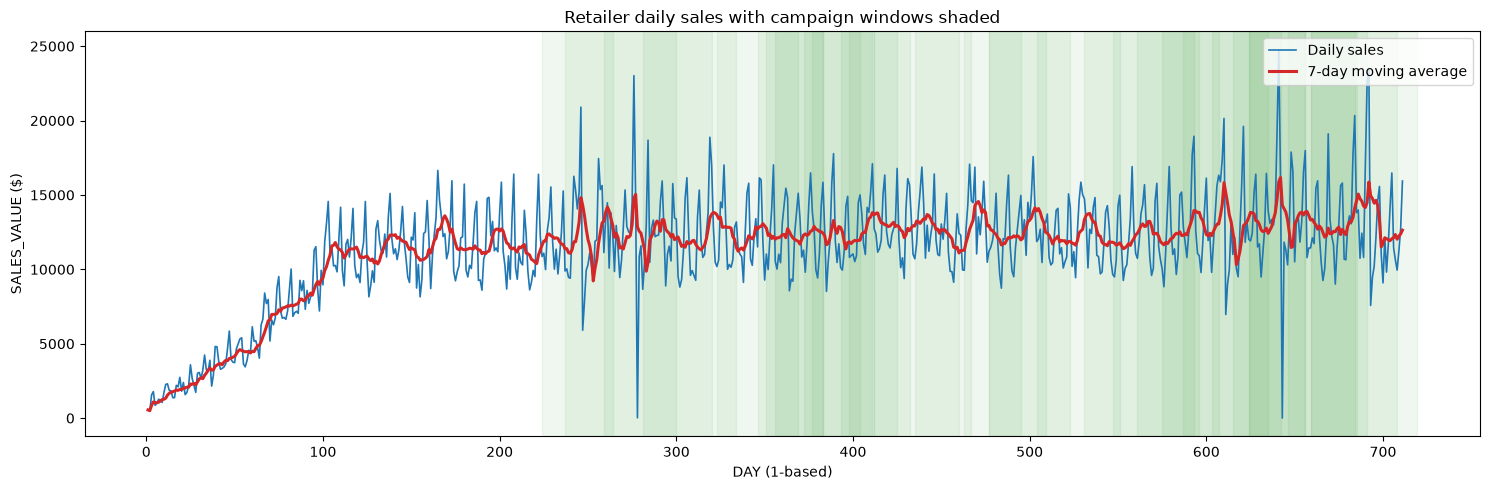

Saved figure -> /home/mhseddighi/Projects/promotion-intelligence/outputs/promotion_analysis/figures/daily_sales_timeline.png


In [6]:
# Figure 1: retailer sales timeline with campaign windows shaded
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily["DAY"], daily["sales"], lw=1.2, color="#1f77b4", label="Daily sales")
ax.plot(daily["DAY"], daily["sales_ma7"], lw=2.2, color="#d62728", label="7-day moving average")
for _, camp in campaign_desc.iterrows():
    ax.axvspan(camp["START_DAY"], camp["END_DAY"], alpha=0.06, color="green")
ax.set_title("Retailer daily sales with campaign windows shaded")
ax.set_xlabel("DAY (1-based)")
ax.set_ylabel("SALES_VALUE ($)")
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(CFG.figures_dir / "daily_sales_timeline.png", dpi=110)
plt.show()
print(f"Saved figure -> {CFG.figures_dir / 'daily_sales_timeline.png'}")


# ## 3. Promoted Products
#
# A campaign "promotes" a product when the product is price-discounted inside the
# campaign window. We derive product x campaign promotion instances from
# transactions (`RETAIL_DISC < 0`) — no heuristics about what *should* be promoted.
# This table is the shared promotion-history input for notebooks 05-09.


In [7]:
promoted = UD.promoted_products_by_discount(tx, campaign_desc)
promoted = promoted.merge(
    products[["PRODUCT_ID", "DEPARTMENT", "COMMODITY_DESC", "BRAND"]],
    on="PRODUCT_ID", how="left",
)
promoted["discount_depth"] = np.where(
    promoted["promo_sales"] + promoted["promo_discount"] > 0,
    promoted["promo_discount"] / (promoted["promo_sales"] + promoted["promo_discount"]),
    0.0,
)
UC.save_parquet(promoted, CFG.output_dir / "promoted_products.parquet",
                logger=logger, context="promoted_products")

# Product-day aggregates reused by 07_cannibalization
pd_daily = tx.groupby(["PRODUCT_ID", "DAY"], as_index=False).agg(
    quantity=("QUANTITY", "sum"),
    sales_value=("SALES_VALUE", "sum"),
    retail_disc=("RETAIL_DISC", "sum"),
)
UC.save_parquet(pd_daily, CFG.output_dir / "product_daily.parquet",
                logger=logger, context="product_daily")

print(f"Promotion instances : {len(promoted):,} (product x campaign)")
print(f"Distinct promoted products: {promoted['PRODUCT_ID'].nunique():,}")
print(f"Avg promoted products per campaign: {promoted.groupby('CAMPAIGN').size().mean():,.0f}")


22:00:16 | INFO    | promotion_analysis | [promoted_products] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/promotion_analysis/promoted_products.parquet (404,361 rows x 12 cols)


22:00:18 | INFO    | promotion_analysis | [product_daily] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/promotion_analysis/product_daily.parquet (1,847,974 rows x 5 cols)


Promotion instances : 404,361 (product x campaign)
Distinct promoted products: 40,925
Avg promoted products per campaign: 13,479


In [8]:
def validate_promoted(promoted: pd.DataFrame) -> None:
    """Every campaign must be covered; schema and NaN checks."""
    assert not promoted.empty, "no promotion instances found"
    missing_camps = set(campaign_desc["CAMPAIGN"]) - set(promoted["CAMPAIGN"])
    assert not missing_camps, f"campaigns without promoted products: {missing_camps}"
    UC.check_schema(promoted, ["PRODUCT_ID", "CAMPAIGN", "promo_days", "promo_sales",
                               "promo_discount", "discount_depth"], context="promoted_products")
    UC.check_no_nan_inf(promoted, context="promoted_products")
    assert (promoted["promo_sales"] >= 0).all() and (promoted["promo_discount"] >= 0).all()
    UC.check_schema(pd_daily, ["PRODUCT_ID", "DAY", "quantity", "sales_value"],
                    context="product_daily")
    print("PASS: promoted products validated")


validate_promoted(promoted)


PASS [schema] promoted_products: 12 columns OK


PASS [nan/inf] promoted_products: no NaN/Inf in 404,361 rows
PASS [schema] product_daily: 5 columns OK
PASS: promoted products validated


# ## 4. Before / During / After Comparison
#
# For every campaign we compare the retailer-level daily averages of **sales, revenue
# (sales value), quantity and discount** across three windows:
#
# - **Before**  : 28 days before `START_DAY`
# - **During**  : `START_DAY .. END_DAY`
# - **After**   : 28 days after `END_DAY`
#
# Uplift is measured against the pre-window baseline (`% change in daily average`).
# The pre-window is the *descriptive* baseline for MVP 01; MVP 02 replaces it with a
# model-based counterfactual forecast.


In [9]:
def window_stats(daily: pd.DataFrame, s: int, e: int) -> pd.Series:
    """Daily averages of the retailer-level metrics in [s, e] (clipped to data range)."""
    s = max(1, int(s))
    e = min(CFG.max_day, int(e))
    if s > e:
        return pd.Series({"n_days": 0, "sales_daily": np.nan, "qty_daily": np.nan,
                          "disc_daily": np.nan, "baskets_daily": np.nan})
    w = daily[(daily["DAY"] >= s) & (daily["DAY"] <= e)]
    if len(w) == 0:
        return pd.Series({"n_days": 0, "sales_daily": np.nan, "qty_daily": np.nan,
                          "disc_daily": np.nan, "baskets_daily": np.nan})
    return pd.Series({
        "n_days": int(len(w)),
        "sales_daily": float(w["sales"].mean()),
        "qty_daily": float(w["quantity"].mean()),
        "disc_daily": float(w["total_discount"].mean()),
        "baskets_daily": float(w["baskets"].mean()),
    })


rows = []
for _, camp in campaign_desc.iterrows():
    cid, s, e = int(camp["CAMPAIGN"]), int(camp["START_DAY"]), int(camp["END_DAY"])
    pre = window_stats(daily, max(1, s - CFG.pre_days), s - 1)
    dur = window_stats(daily, s, e)
    post = window_stats(daily, e + 1, e + CFG.post_days)
    rows.append({
        "CAMPAIGN": cid, "DESCRIPTION": camp["DESCRIPTION"],
        "START_DAY": s, "END_DAY": e, "duration_days": int(camp["duration_days"]),
        **{f"pre_{k}": v for k, v in pre.items()},
        **{f"during_{k}": v for k, v in dur.items()},
        **{f"post_{k}": v for k, v in post.items()},
    })

summary = pd.DataFrame(rows)
for metric in ["sales", "qty", "disc", "baskets"]:
    summary[f"{metric}_uplift_pct"] = (
        (summary[f"during_{metric}_daily"] - summary[f"pre_{metric}_daily"])
        / summary[f"pre_{metric}_daily"] * 100.0
    )
summary["discount_depth_pct"] = np.where(
    summary["during_sales_daily"] > 0,
    summary["during_disc_daily"] / summary["during_sales_daily"] * 100.0,
    0.0,
)

UC.save_parquet(summary, CFG.output_dir / "campaign_summary.parquet",
                logger=logger, context="campaign_summary")
print(summary[["CAMPAIGN", "DESCRIPTION", "duration_days",
               "pre_sales_daily", "during_sales_daily", "post_sales_daily",
               "sales_uplift_pct", "qty_uplift_pct"]].round(2).to_string(index=False))


22:00:18 | INFO    | promotion_analysis | [campaign_summary] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/promotion_analysis/campaign_summary.parquet (30 rows x 25 cols)


 CAMPAIGN DESCRIPTION  duration_days  pre_sales_daily  during_sales_daily  post_sales_daily  sales_uplift_pct  qty_uplift_pct
       24       TypeB             61         13461.17            13058.01               NaN             -2.99            2.98
       15       TypeC            162         12366.61            12914.60          13314.16              4.43           -4.14
       25       TypeB             33         13461.17            13413.20          12471.95             -0.36            7.18
       20       TypeC             71         13141.78            13221.17          12961.17              0.60           -1.32
       23       TypeB             39         13340.30            13285.97          12992.70             -0.41            5.66
       21       TypeB             33         12935.54            13509.53          12981.93              4.44           -3.85
       22       TypeB             33         12935.54            13509.53          12981.93              4.44         

In [10]:
# Product-level uplift for the top promoted products of every campaign
top = (promoted.sort_values("promo_sales", ascending=False)
              .groupby("CAMPAIGN", as_index=False)
              .head(CFG.top_products_per_campaign)
              [["CAMPAIGN", "PRODUCT_ID", "START_DAY", "END_DAY", "promo_sales"]])
top["pre_start"] = (top["START_DAY"] - CFG.pre_days).clip(lower=1)

m = top.merge(pd_daily, on="PRODUCT_ID", how="left")
pre = (m[(m["DAY"] >= m["pre_start"]) & (m["DAY"] < m["START_DAY"])]
        .groupby(["CAMPAIGN", "PRODUCT_ID"], as_index=False)
        .agg(pre_qty=("quantity", "sum"), pre_sales=("sales_value", "sum")))
dur = (m[(m["DAY"] >= m["START_DAY"]) & (m["DAY"] <= m["END_DAY"])]
        .groupby(["CAMPAIGN", "PRODUCT_ID"], as_index=False)
        .agg(dur_qty=("quantity", "sum"), dur_sales=("sales_value", "sum")))
product_uplift = (top.merge(pre, on=["CAMPAIGN", "PRODUCT_ID"], how="left")
                      .merge(dur, on=["CAMPAIGN", "PRODUCT_ID"], how="left")
                      .merge(products[["PRODUCT_ID", "COMMODITY_DESC", "DEPARTMENT"]],
                             on="PRODUCT_ID", how="left"))
for col in ["pre_qty", "pre_sales", "dur_qty", "dur_sales"]:
    product_uplift[col] = product_uplift[col].fillna(0.0)
product_uplift["qty_uplift_pct"] = np.where(
    product_uplift["pre_qty"] > 0,
    (product_uplift["dur_qty"] / product_uplift["pre_qty"] - 1.0) * 100.0,
    np.nan,
)
UC.save_parquet(product_uplift, CFG.output_dir / "product_uplift.parquet",
                logger=logger, context="product_uplift")
print(product_uplift[["CAMPAIGN", "PRODUCT_ID", "COMMODITY_DESC",
                      "pre_qty", "dur_qty", "qty_uplift_pct"]]
      .dropna().sort_values("qty_uplift_pct", ascending=False).head(10).to_string(index=False))


22:00:18 | INFO    | promotion_analysis | [product_uplift] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/promotion_analysis/product_uplift.parquet (300 rows x 13 cols)


 CAMPAIGN  PRODUCT_ID      COMMODITY_DESC  pre_qty  dur_qty  qty_uplift_pct
       18      914190              CHEESE     93.0     1252     1246.236559
       15     1070702                BEEF     37.0      428     1056.756757
       20     5569471         SOFT DRINKS     48.0      469      877.083333
       20     1133018 FLUID MILK PRODUCTS    166.0     1608      868.674699
       20      995242 FLUID MILK PRODUCTS    320.0     2747      758.437500
       15      844179                BEEF    219.0     1657      656.621005
        6     6544236   COUPON/MISC ITEMS  36245.0   266607      635.569044
       15     1029743 FLUID MILK PRODUCTS    703.0     4410      527.311522
       15     6533889   COUPON/MISC ITEMS 937142.0  5487379      485.544026
        9     1044078                BEEF    101.0      587      481.188119


# ## 5. Promotion Uplift Visualization
#
# We visualise three views: example campaign timelines (before/during/after shaded),
# the aggregate uplift per campaign, and the comparison by campaign type.


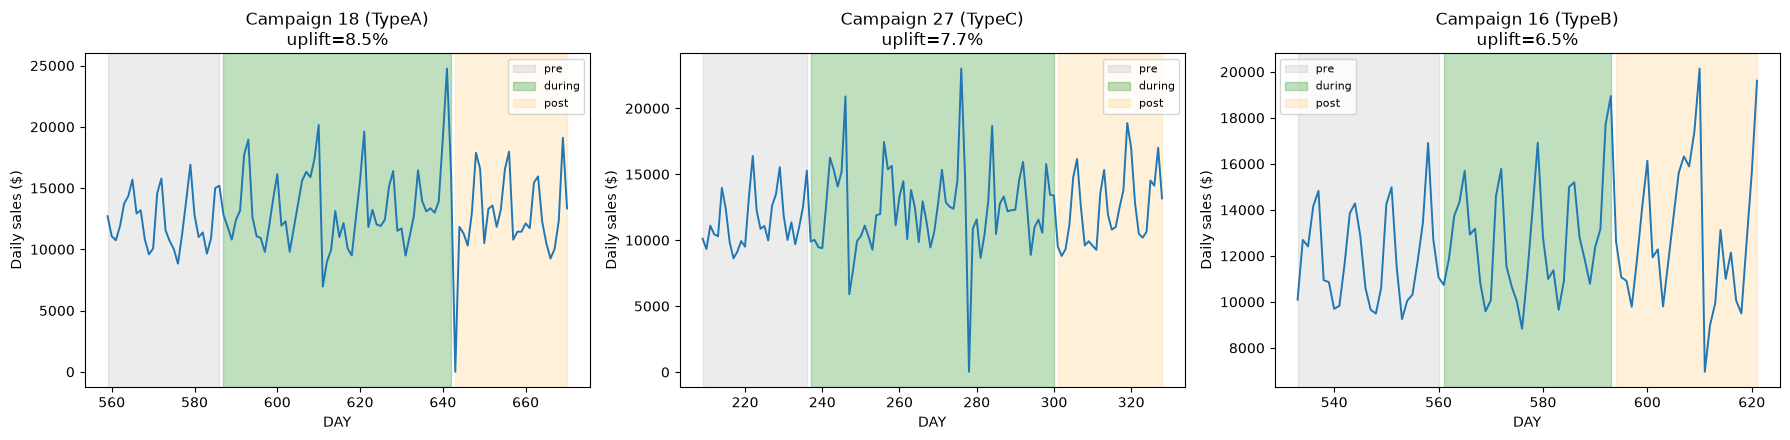

In [11]:
# Example campaigns: one strongly positive, one negative, one typical
examples = summary.reindex(summary["sales_uplift_pct"].abs().sort_values(ascending=False).index).head(3)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (_, camp) in zip(axes, examples.iterrows()):
    cid, s, e = int(camp["CAMPAIGN"]), int(camp["START_DAY"]), int(camp["END_DAY"])
    lo, hi = max(1, s - CFG.pre_days), e + CFG.post_days
    win = daily[(daily["DAY"] >= lo) & (daily["DAY"] <= hi)]
    ax.plot(win["DAY"], win["sales"], lw=1.4, color="#1f77b4")
    ax.axvspan(max(1, s - CFG.pre_days), s - 1, alpha=0.15, color="gray", label="pre")
    ax.axvspan(s, e, alpha=0.25, color="green", label="during")
    ax.axvspan(e + 1, e + CFG.post_days, alpha=0.15, color="orange", label="post")
    ax.set_title(f"Campaign {cid} ({camp['DESCRIPTION']})\nuplift={camp['sales_uplift_pct']:.1f}%")
    ax.set_xlabel("DAY"); ax.set_ylabel("Daily sales ($)")
    ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(CFG.figures_dir / "example_campaigns.png", dpi=110)
plt.show()


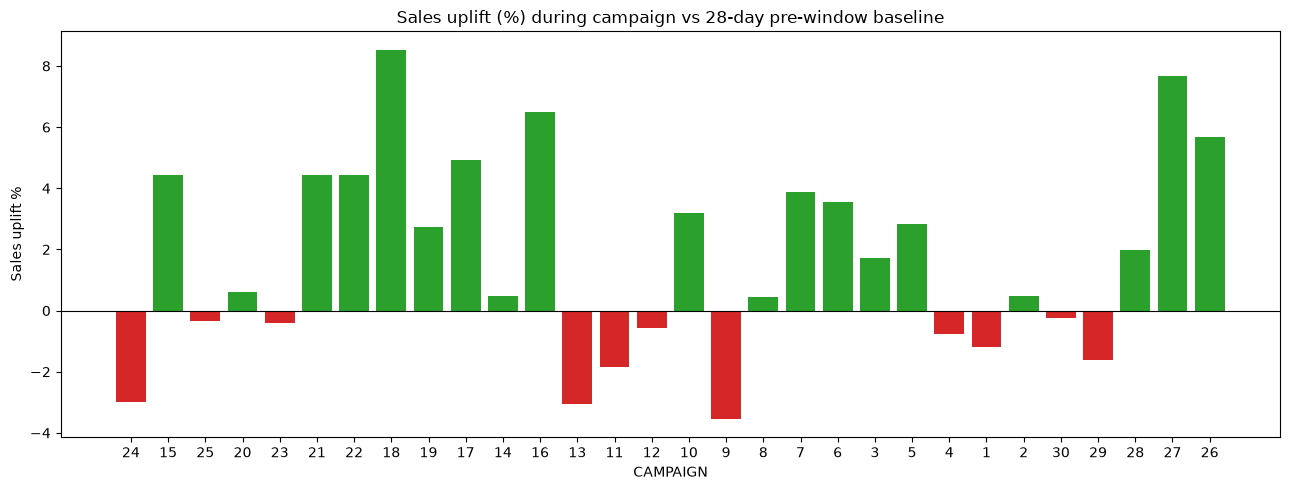

In [12]:
fig, ax = plt.subplots(figsize=(13, 5))
colors = np.where(summary["sales_uplift_pct"] >= 0, "#2ca02c", "#d62728")
ax.bar(summary["CAMPAIGN"].astype(str), summary["sales_uplift_pct"], color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Sales uplift (%) during campaign vs 28-day pre-window baseline")
ax.set_xlabel("CAMPAIGN"); ax.set_ylabel("Sales uplift %")
plt.tight_layout()
fig.savefig(CFG.figures_dir / "campaign_uplift.png", dpi=110)
plt.show()


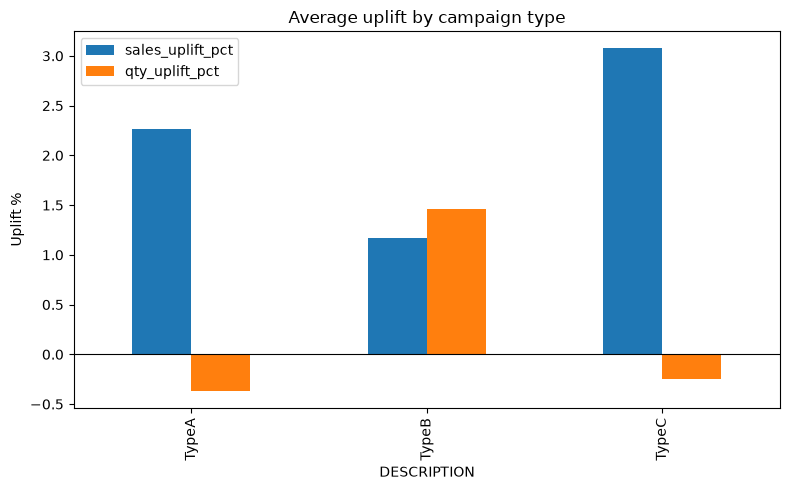

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
type_stats = summary.groupby("DESCRIPTION")[["sales_uplift_pct", "qty_uplift_pct"]].mean()
type_stats.plot(kind="bar", ax=ax)
ax.set_title("Average uplift by campaign type")
ax.set_ylabel("Uplift %")
ax.axhline(0, color="black", lw=0.8)
plt.tight_layout()
fig.savefig(CFG.figures_dir / "type_comparison.png", dpi=110)
plt.show()


# ## 6. Baseline Descriptive Statistics
#
# Descriptive statistics for the retailer-level baseline (pre-window) and the uplift
# distribution. These numbers are the descriptive counterpart of the model-based
# baseline produced in MVP 02.


In [14]:
print("=== Baseline (pre-window) descriptive statistics — retailer level ===")
print(summary[["pre_sales_daily", "pre_qty_daily", "pre_disc_daily", "pre_baskets_daily"]]
      .describe().round(2).to_string())

print("\n=== Uplift distribution (%) ===")
print(summary[["sales_uplift_pct", "qty_uplift_pct", "discount_depth_pct"]]
      .describe().round(2).to_string())

print("\n=== By campaign type ===")
print(summary.groupby("DESCRIPTION")[["sales_uplift_pct", "qty_uplift_pct",
                                      "discount_depth_pct"]].mean().round(2).to_string())

print("\n=== Duration distribution by type (days) ===")
print(summary.groupby("DESCRIPTION")["duration_days"].describe().round(1).to_string())


=== Baseline (pre-window) descriptive statistics — retailer level ===
       pre_sales_daily  pre_qty_daily  pre_disc_daily  pre_baskets_daily
count            30.00          30.00           30.00              30.00
mean          12520.23      416110.33         2227.47             424.01
std             476.00       23178.38          122.89               8.40
min           11494.51      385240.39         2004.86             411.96
25%           12290.15      397223.70         2145.29             418.69
50%           12393.81      406619.34         2229.34             421.52
75%           12683.67      433486.24         2278.44             426.48
max           13461.17      459904.29         2481.56             444.07

=== Uplift distribution (%) ===
       sales_uplift_pct  qty_uplift_pct  discount_depth_pct
count             30.00           30.00               30.00
mean               1.73            0.81               17.79
std                3.22            4.60                0.57


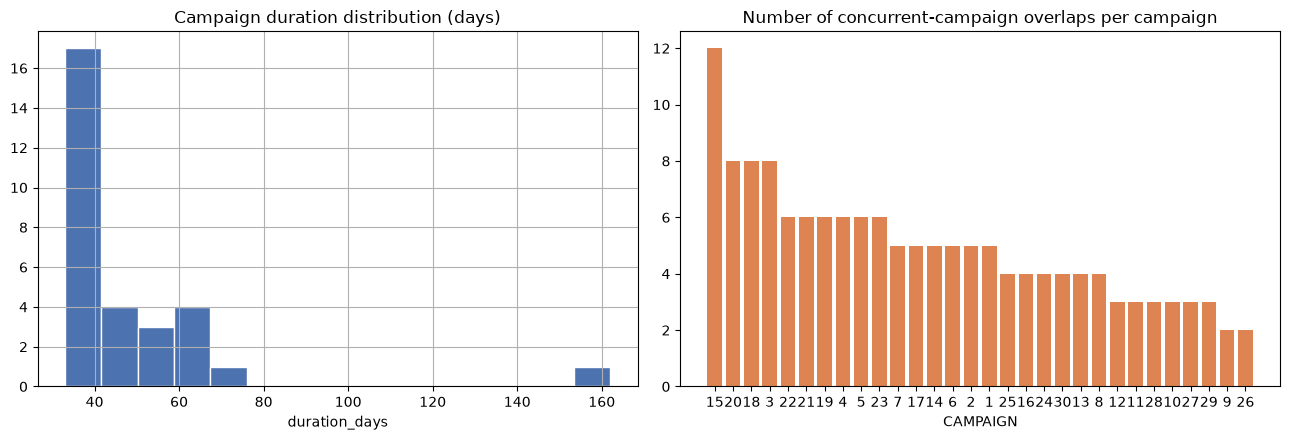

In [15]:
# Figure: duration distribution + overlap count
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
summary["duration_days"].hist(bins=15, ax=axes[0], color="#4c72b0", edgecolor="white")
axes[0].set_title("Campaign duration distribution (days)")
axes[0].set_xlabel("duration_days")
if not overlaps.empty:
    overlap_counts = (pd.concat([overlaps["campaign_a"], overlaps["campaign_b"]])
                        .value_counts().rename("overlap_count"))
    axes[1].bar(overlap_counts.index.astype(str), overlap_counts.values, color="#dd8452")
    axes[1].set_title("Number of concurrent-campaign overlaps per campaign")
    axes[1].set_xlabel("CAMPAIGN")
plt.tight_layout()
fig.savefig(CFG.figures_dir / "duration_overlap.png", dpi=110)
plt.show()


In [16]:
# Export remaining artifacts: daily timeline and overlap table
UC.save_parquet(daily, CFG.output_dir / "campaign_timeline.parquet",
                logger=logger, context="campaign_timeline")
if not overlaps.empty:
    UC.save_parquet(overlaps, CFG.output_dir / "campaign_overlaps.parquet",
                    logger=logger, context="campaign_overlaps")


22:00:22 | INFO    | promotion_analysis | [campaign_timeline] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/promotion_analysis/campaign_timeline.parquet (711 rows x 10 cols)


22:00:22 | INFO    | promotion_analysis | [campaign_overlaps] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/promotion_analysis/campaign_overlaps.parquet (74 rows x 7 cols)


# ## 7. Validation — Exports, Schema and Reload
#
# Every exported artifact is re-loaded and checked for schema consistency, NaN / Inf
# values and row counts. This is the contract notebooks 05-09 rely on.


In [17]:
def validate_exports() -> None:
    out = CFG.output_dir
    summary_check = UC.reload_and_check(out / "campaign_summary.parquet",
        expected=["CAMPAIGN", "DESCRIPTION", "START_DAY", "END_DAY", "duration_days",
                  "sales_uplift_pct", "qty_uplift_pct", "discount_depth_pct"],
        context="campaign_summary")
    assert len(summary_check) == len(campaign_desc), "summary row count mismatch"

    timeline_check = UC.reload_and_check(out / "campaign_timeline.parquet",
        expected=["DAY", "sales", "quantity", "total_discount", "campaign_active"],
        context="campaign_timeline")
    assert timeline_check["DAY"].is_monotonic_increasing

    prom_check = UC.reload_and_check(out / "promoted_products.parquet",
        expected=["PRODUCT_ID", "CAMPAIGN", "promo_days", "promo_sales",
                  "promo_discount", "discount_depth"],
        context="promoted_products")
    assert prom_check["CAMPAIGN"].nunique() == len(campaign_desc)

    UC.reload_and_check(out / "product_daily.parquet",
        expected=["PRODUCT_ID", "DAY", "quantity", "sales_value"], context="product_daily")
    pu = UC.reload_and_check(out / "product_uplift.parquet",
        expected=["CAMPAIGN", "PRODUCT_ID", "pre_qty", "dur_qty", "qty_uplift_pct"],
        context="product_uplift", allow_nan_cols=["qty_uplift_pct"])
    assert (pu["dur_qty"] >= 0).all() and (pu["pre_qty"] >= 0).all()
    print("PASS: all MVP 01 exports validated")


validate_exports()


PASS [nan/inf] reload campaign_summary.parquet: no NaN/Inf in 30 rows
PASS [schema] reload campaign_summary.parquet: 25 columns OK
PASS [reload] campaign_summary: campaign_summary.parquet -> 30 rows
PASS [nan/inf] reload campaign_timeline.parquet: no NaN/Inf in 711 rows
PASS [schema] reload campaign_timeline.parquet: 10 columns OK
PASS [reload] campaign_timeline: campaign_timeline.parquet -> 711 rows
PASS [nan/inf] reload promoted_products.parquet: no NaN/Inf in 404,361 rows
PASS [schema] reload promoted_products.parquet: 12 columns OK
PASS [reload] promoted_products: promoted_products.parquet -> 404,361 rows


PASS [nan/inf] reload product_daily.parquet: no NaN/Inf in 1,847,974 rows
PASS [schema] reload product_daily.parquet: 5 columns OK
PASS [reload] product_daily: product_daily.parquet -> 1,847,974 rows
PASS [nan/inf] reload product_uplift.parquet: no NaN/Inf in 300 rows
PASS [schema] reload product_uplift.parquet: 13 columns OK
PASS [reload] product_uplift: product_uplift.parquet -> 300 rows
PASS: all MVP 01 exports validated


In [18]:
# Pipeline manifest snippet (full manifest is assembled in the final notebook run)
manifest = {
    "notebook": "04_promotion_analysis",
    "mvp": "MVP 01 — Promotion Impact Analysis",
    "inputs": ["data/raw/transaction_data.csv", "data/raw/product.csv",
               "data/raw/campaign_desc.csv", "data/raw/campaign_table.csv",
               "data/raw/causal_data.csv"],
    "outputs": [
        "outputs/promotion_analysis/campaign_summary.parquet",
        "outputs/promotion_analysis/campaign_timeline.parquet",
        "outputs/promotion_analysis/promoted_products.parquet",
        "outputs/promotion_analysis/product_daily.parquet",
        "outputs/promotion_analysis/product_uplift.parquet",
        "outputs/promotion_analysis/campaign_overlaps.parquet",
        "data/processed/causal_weekly.parquet",
    ],
    "artifacts": {
        "campaign_summary.parquet": "per-campaign before/during/after daily averages + uplift",
        "promoted_products.parquet": "product x campaign promotion instances (shared promotion history)",
        "causal_weekly.parquet": "product-week display/mailer intensity (shared cache)",
    },
}
print(json.dumps(manifest, indent=2))


{
  "notebook": "04_promotion_analysis",
  "mvp": "MVP 01 \u2014 Promotion Impact Analysis",
  "inputs": [
    "data/raw/transaction_data.csv",
    "data/raw/product.csv",
    "data/raw/campaign_desc.csv",
    "data/raw/campaign_table.csv",
    "data/raw/causal_data.csv"
  ],
  "outputs": [
    "outputs/promotion_analysis/campaign_summary.parquet",
    "outputs/promotion_analysis/campaign_timeline.parquet",
    "outputs/promotion_analysis/promoted_products.parquet",
    "outputs/promotion_analysis/product_daily.parquet",
    "outputs/promotion_analysis/product_uplift.parquet",
    "outputs/promotion_analysis/campaign_overlaps.parquet",
    "data/processed/causal_weekly.parquet"
  ],
  "artifacts": {
    "campaign_summary.parquet": "per-campaign before/during/after daily averages + uplift",
    "promoted_products.parquet": "product x campaign promotion instances (shared promotion history)",
    "causal_weekly.parquet": "product-week display/mailer intensity (shared cache)"
  }
}
